In [7]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [8]:
df = pd.read_excel("P652-Dataset.xlsx")

In [9]:
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [12]:
df.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [17]:
df.describe()

,rating
count,1440.000000
mean,3.173611
std,1.584453
min,1.000000
25%,1.000000
50%,4.000000
75%,5.000000
max,5.000000


In [19]:
df = df.dropna(subset=['body', 'rating'])

In [22]:
def get_sentiment(rating):
    if rating in [4, 5]:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    elif rating in [1, 2]:
        return 'Negative'

print("Sentiment categorization function 'get_sentiment' defined.")

Sentiment categorization function 'get_sentiment' defined.


In [24]:
df['sentiment'] = df['rating'].apply(get_sentiment)
df.head()

,title,rating,body,sentiment
0,Horrible product,1,Very disappointed with the overall performance...,Negative
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative


In [26]:
print(df['sentiment'].value_counts())

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64


In [28]:
print("Sample Positive Reviews ")
print(df[df['sentiment'] == 'Positive'].head()[['body', 'sentiment']])

print("Sample Neutral Reviews ")
print(df[df['sentiment'] == 'Neutral'].head()[['body', 'sentiment']])

print(" Sample Negative Reviews")
print(df[df['sentiment'] == 'Negative'].head()[['body', 'sentiment']])

Sample Positive Reviews 
                                                 body sentiment
2   Got the mobile on the launch date,Battery must...  Positive
14  Just unboxed the phone.Seems to be a better on...  Positive
19  This is perfect phone, good speed, decent spec...  Positive
28  A very satisfying  experience with the device ...  Positive
33  It's a real monster. Everything is awesome fro...  Positive
Sample Neutral Reviews 
                                                 body sentiment
1                               Camera quality is low   Neutral
23  The media could not be loaded.\n              ...   Neutral
30  Pros:1. The biggest advantage for buying this ...   Neutral
42  This phone has 90hz display, but I see a lag w...   Neutral
47  Good phone in decent budget .Display could've ...   Neutral
 Sample Negative Reviews
                                                body sentiment
0  Very disappointed with the overall performance...  Negative
3  1. It doesn't work with 5.0GH

C:\Users\HP\AppData\Local\Temp\ipykernel_2876\785701262.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['sentiment'], palette='viridis')


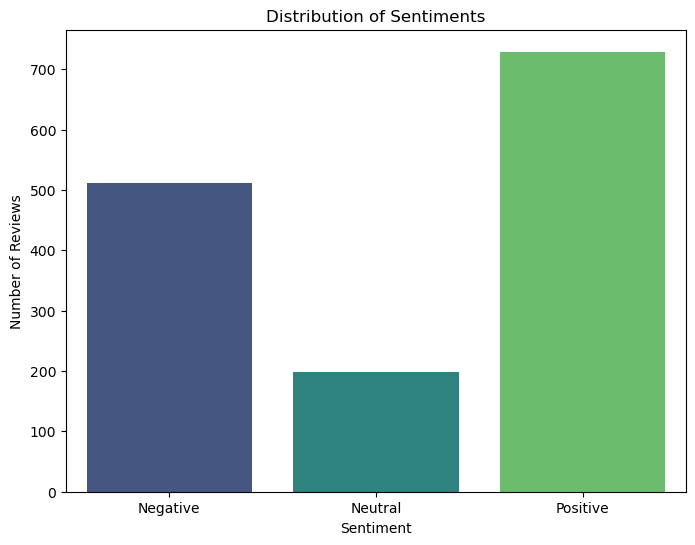

In [30]:
plt.figure(figsize=(8, 6))
sns.countplot(x=df['sentiment'], palette='viridis')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

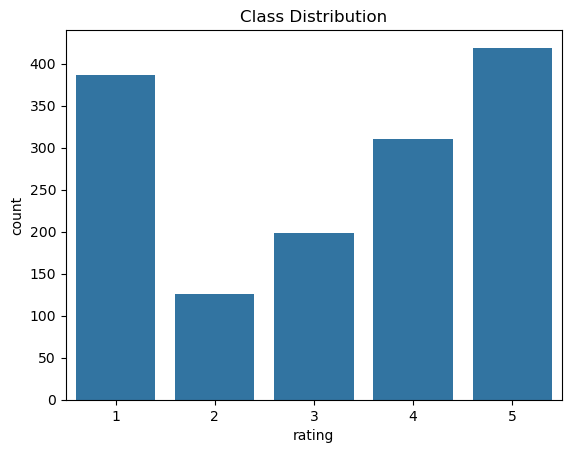

In [32]:
# Class distribution
plt.figure()
sns.countplot(x=df['rating'])
plt.title("Class Distribution")
plt.show()

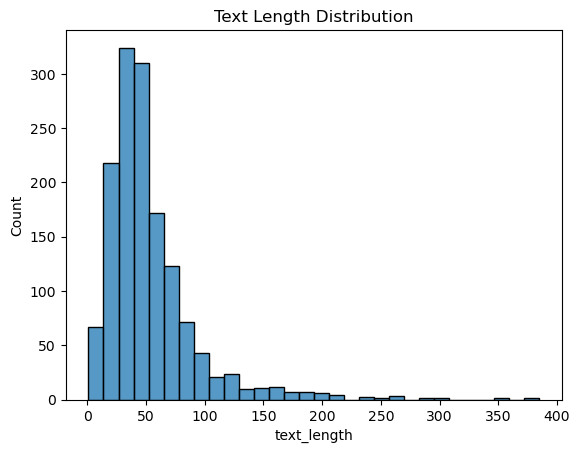

In [34]:
# Text length distribution
df["text_length"] = df['body'].apply(lambda x: len(str(x).split()))

plt.figure()
sns.histplot(df["text_length"], bins=30)
plt.title("Text Length Distribution")
plt.show()

In [36]:
# TEXT CLEANING (Keep 'not', 'no')
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))
stop_words.remove("not")
stop_words.remove("no")

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df["cleaned_text"] = df['body'].apply(clean_text)

print("Cleaned Text Sample:")
print(df["cleaned_text"].head())

Cleaned Text Sample:
0             disappointed overall performance samsung
1                                   camera quality low
2    got mobile launch datebattery must appreciated...
3    doesnt work ghz wifi frequency ghz old school ...
4    not worth buyingfaulty software poor display q...
Name: cleaned_text, dtype: object


In [37]:
# WORD FREQUENCY ANALYSIS
all_words = " ".join(df["cleaned_text"]).split()
word_freq = Counter(all_words)

word_freq_df = pd.DataFrame(word_freq.items(), columns=["word", "frequency"])
word_freq_df = word_freq_df.sort_values(by="frequency", ascending=False)

print("Top 20 Words:")
print(word_freq_df.head(20))

Top 20 Words:
        word  frequency
66     phone       1555
69       not       1159
30      good       1080
4     camera        870
206  battery        711
3    samsung        612
5    quality        611
8     mobile        513
248      day        342
173    price        334
105  product        310
240     also        301
184     life        282
67      like        279
74   display        264
32        no        255
104      buy        248
54       one        233
505      use        229
172   better        228


In [38]:
# BIGRAM FREQUENCY ANALYSIS
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), min_df=5)
X_bigrams = bigram_vectorizer.fit_transform(df["cleaned_text"])

bigram_freq = np.sum(X_bigrams.toarray(), axis=0)

bigram_df = pd.DataFrame({
    "bigram": bigram_vectorizer.get_feature_names_out(),
    "frequency": bigram_freq
}).sort_values(by="frequency", ascending=False)

print("Top 20 Bigrams:")
print(bigram_df.head(20))


Top 20 Bigrams:
             bigram  frequency
103  camera quality        229
39     battery life        226
422        not good        116
563     price range         85
226    good battery         74
31   battery backup         73
193    finger print         70
589     quality not         68
211          gb ram         61
252      good phone         61
152        dont buy         59
503      phone good         57
95       camera not         55
67     budget phone         55
616    refresh rate         55
588    quality good         54
342     mah battery         53
229     good camera         52
199    front camera         51
445     not working         47


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [42]:
df["text"] = df["title"] + " " + df["body"]

In [46]:
X = df["text"]
y = df["sentiment"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [50]:
vectorizer = TfidfVectorizer(stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

 # Model Bulding

In [53]:
#Logistic Regression

In [55]:
lr = LogisticRegression()

lr.fit(X_train_vec, y_train)

pred_lr = lr.predict(X_test_vec)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Logistic Regression Accuracy: 0.7986111111111112
              precision    recall  f1-score   support

    Negative       0.90      0.86      0.88       111
     Neutral       1.00      0.09      0.17        44
    Positive       0.73      0.98      0.84       133

    accuracy                           0.80       288
   macro avg       0.88      0.64      0.63       288
weighted avg       0.84      0.80      0.75       288



In [57]:
# Navie Bayes 

In [59]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report # Import necessary metrics

nb = MultinomialNB()

nb.fit(X_train_vec, y_train)

pred_nb = nb.predict(X_test_vec)

print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))
print(classification_report(y_test, pred_nb, zero_division=0))

Naive Bayes Accuracy: 0.7083333333333334
              precision    recall  f1-score   support

    Negative       0.96      0.65      0.77       111
     Neutral       0.00      0.00      0.00        44
    Positive       0.62      0.99      0.76       133

    accuracy                           0.71       288
   macro avg       0.53      0.55      0.51       288
weighted avg       0.66      0.71      0.65       288



In [61]:
# SVM

In [63]:
svm = LinearSVC()

svm.fit(X_train_vec, y_train)

pred_svm = svm.predict(X_test_vec)

print("SVM Accuracy:", accuracy_score(y_test, pred_svm))
print(classification_report(y_test, pred_svm))

SVM Accuracy: 0.8194444444444444
              precision    recall  f1-score   support

    Negative       0.92      0.87      0.90       111
     Neutral       0.73      0.25      0.37        44
    Positive       0.76      0.96      0.85       133

    accuracy                           0.82       288
   macro avg       0.81      0.70      0.71       288
weighted avg       0.82      0.82      0.80       288



In [65]:
# Random Forest

In [67]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train_vec, y_train)

pred_rf = rf.predict(X_test_vec)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf, zero_division=0))

Random Forest Accuracy: 0.7604166666666666
              precision    recall  f1-score   support

    Negative       0.90      0.78      0.84       111
     Neutral       1.00      0.02      0.04        44
    Positive       0.69      0.98      0.81       133

    accuracy                           0.76       288
   macro avg       0.86      0.60      0.56       288
weighted avg       0.82      0.76      0.70       288



In [68]:
# Decision tree

In [69]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train_vec, y_train)

pred_dt = dt.predict(X_test_vec)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))

Decision Tree Accuracy: 0.6805555555555556
              precision    recall  f1-score   support

    Negative       0.72      0.75      0.73       111
     Neutral       0.22      0.14      0.17        44
    Positive       0.73      0.80      0.77       133

    accuracy                           0.68       288
   macro avg       0.56      0.56      0.56       288
weighted avg       0.65      0.68      0.66       288



# Model evalution

In [74]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "SVM",
        "Random Forest",
        "Decision Tree"
    ],

    "Accuracy":[
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_svm),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_dt)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.798611
1          Naive Bayes  0.708333
2                  SVM  0.819444
3        Random Forest  0.760417
4        Decision Tree  0.680556


In [76]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_svm)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 97   2  12]
 [  5  11  28]
 [  3   2 128]]


In [78]:
print("Classification Report:\n")

print(classification_report(y_test, pred_svm))

Classification Report:

              precision    recall  f1-score   support

    Negative       0.92      0.87      0.90       111
     Neutral       0.73      0.25      0.37        44
    Positive       0.76      0.96      0.85       133

    accuracy                           0.82       288
   macro avg       0.81      0.70      0.71       288
weighted avg       0.82      0.82      0.80       288



In [ ]:
#Confusion Matrix Visualization

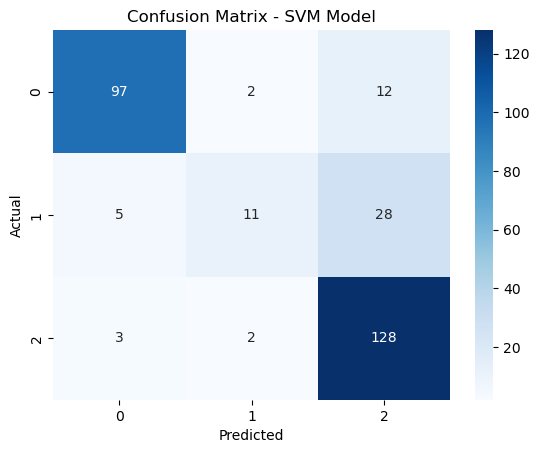

In [80]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM Model")

plt.show()